# Preliminaries

[next cells set up the python environment &
customizations]

In [131]:
from matplotlib import pyplot as plt
from matplotlib import transforms as mtransforms
from matplotlib import ticker
size = 16
params = {'legend.fontsize': 'medium',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.grid': False,
          'axes.titlepad': 25,
          'font.family': 'serif',
          'mathtext.fontset': 'cm'}
plt.rcParams.update(params)
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy import special as sc
from sklearn.metrics import r2_score

# from google.colab import files

## Credit

Accomapying Jupyter notebook for the manuscript by [Chun _et al._](#References).

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

3D microchannel with plate-like top wall solution is based on the paper by [Anand _et al._ (2019)](#References).

Axisymmetric extruded microtube solution is based on the papers [Wang _et al._ (2022)](#References) and [Christov (2022)](#References).

Experiments performed by/at [FIT Lab | Feng Research Group](https://fengfluidslab.web.illinois.edu/) at University of Illinois at Urbana-Champaign.

# 3D microchannel with plate-like deformable top wall

## Parameters

All parameters are given in SI units using MKS.

### Geometry and solid material properties

Parameters of geometric configurations used experiments are measured after being manufactured.

Material properties of PDMS are measured after it is cooked/cured.

In [132]:
# from Anand et al.
# h0 = 0.155 * (1e-3)
# from FIT Lab
h0 = 0.25 * (1e-3)
h0_err = 0.02 * (1e-3)

# from Anand et al.
# w = 1.7 * (1e-3)
# from FIT Lab
w = 5 * (1e-3)  # +/- 0.2

# from Anand et al.
# l = 15.5 * (1e-3)
# from FIT Lab
l = {}
l['channel'] = 26 * (1e-3)  # +/- 0.3
l['channel dp'] = 26 * (1e-3)  # l = l_dp by design

# from Anand et al.
# t = 0.605 * (1e-3)
# from FIT Lab
t = 0.48 * (1e-3)  # +/- 0.05

# Young's modulus, on the order of 1 MPa
# from FIT Lab
E = {}
E['channel'] = 0.92 * (1e6)
E_err = {}
E_err['channel'] = 0.05 * (1e6)

# Poisson ratio, anything close to 0.5 is fine
# nu_s = 0.499
# from FIT Lab
nu_s = 0.47  # 0.46 to 0.48

# computed plate's bending rigidity
B = E['channel']*t**3/(12*(1-nu_s**2))

# shear correction factor for plate
# = 1, unless you have very good reason
kappa = 1

Compute several geometric ratios (dimensionless)

In [133]:
eps = {}
eps['channel'] = h0/l['channel']
print(f' streamwise channel aspect ratio, epsilon   =', f'{eps["channel"]:.4g}')

delta = h0/w
print(f' spanwise channel aspect ratio,   delta     =', f'{delta:.4g}')

t_w = t/w
print(f' plate wall thickness-to-width ration,  t/w =', f'{t_w:.4g}')

 streamwise channel aspect ratio, epsilon   = 0.009615
 spanwise channel aspect ratio,   delta     = 0.05
 plate wall thickness-to-width ration,  t/w = 0.096


### Fluid's thermophysical properties

In [134]:
# density of fluids, only important for the Reynolds #
rho_DI = 1e3
rho_Gly = rho_DI
rho_XG = rho_DI

# viscosity of DI water
mu_DI = 1e-3

For the Newtonian working fluid, we use a 62% wt glycerin-DI water solution.

In [135]:
rheodata = {}
# experimental data, for 62% wt glycerin solution from 230317
rheodata['Gly viscosity 1'] = np.array([0.0095847, 0.0095731, 0.0096173, 0.0095474,
                                        0.0095681, 0.0095732, 0.0095189, 0.0094361,
                                        0.0095153, 0.0095734])

# experimental data, for 62% wt glycerin solution from 230412
rheodata['Gly viscosity 2'] = np.array([0.01031818, 0.01021392, 0.01028172,
                                        0.01038191, 0.01027181, 0.01017372,
                                        0.01041732, 0.01013717, 0.01043717,
                                        0.01028171])

# both experiments had common shear rates
rheodata['Gly shear rate'] = np.array([6.30956, 9.99999, 15.849, 25.1188, 39.8108,
                                       63.0957, 99.9999, 158.489, 251.189, 398.107])

rheodata['Gly viscosity'] = (rheodata['Gly viscosity 1']+rheodata['Gly viscosity 2'])/2

tmp = np.transpose(np.stack((rheodata['Gly viscosity 1'], rheodata['Gly viscosity 2'])))
rheodata['Gly viscosity err'] = np.sqrt(np.sum((tmp-np.mean(tmp))**2, axis=1)/(2-1))

mu_Gly = np.mean(rheodata['Gly viscosity'])
mu_Gly_err = np.mean(rheodata['Gly viscosity err'])
print(f' viscosity of glycerin solution is {mu_Gly*1e3:.4g} +/- {mu_Gly_err*1e3:.4g} cP')

 viscosity of glycerin solution is 9.921 +/- 0.5295 cP


For the shear-thinning working fluid, a Carreau&ndash;Yasuda fit
$$ \eta(\dot{\gamma})= \eta_\infty + (\eta_{0} - \eta_\infty)\left(1+(\lambda_r\dot{\gamma})^{a}\right)^{(n-1)/a} $$
can be used for xanthan gum rheology. We take $a=2$, reducing it to the Carreau model.

Independently of the choice of $a$, we can also define an equivalent power-law model
$$ \eta(\dot{\gamma})=m\dot{\gamma}^{n-1}, \qquad m = \eta_{0}\lambda_r^{n-1}. $$

We may also consider a truncated power-law (Spriggs model)
$$ \eta(\dot{\gamma})= \begin{cases} \eta_0, &\dot{\gamma}<\dot\lambda_r^{-1},\\ \eta_{0}(\lambda_r\dot{\gamma})^{n-1}, &\text{else}. \end{cases} $$

For Spriggs (and power-law), we can fit the parameters (as $\eta_0$, $m$, $n$ or as $\eta_0$, $\lambda_r$, $n$) direcly, or obtain them from the Carreau fit ($\eta_0$, $\lambda_r$, $n$).

In [136]:
def Carreau(dotgamma, eta_0, eta_inf, lambda_r, n):
    return eta_inf + (eta_0-eta_inf)*pow(1+(lambda_r*dotgamma)**2, (n-1)/2)

def Carreau_log(dotgamma, eta_0, eta_inf, lambda_r, n):
    eta = Carreau(np.exp(dotgamma), eta_0, eta_inf, lambda_r, n)
    return np.log(eta)

def Carreau_Yasuda(dotgamma, eta_0, eta_inf, lambda_r, n, a):
    return eta_inf + (eta_0-eta_inf)*pow(1+(lambda_r*dotgamma)**(a), (n-1)/a)

def Carreau_Yasuda_log(dotgamma, eta_0, eta_inf, lambda_r, n, a):
    eta = Carreau_Yasuda(np.exp(dotgamma), eta_0, eta_inf, lambda_r, n, a)
    return np.log(eta)

def Spriggs(dotgamma, eta_0, lambda_r, n):
    eta = np.zeros_like(dotgamma)
    eta[dotgamma < 1/lambda_r] = eta_0
    eta[dotgamma >= 1/lambda_r] = eta_0 * \
        (lambda_r*dotgamma[dotgamma >= 1/lambda_r])**(n-1)
    return eta

def Spriggs_log(dotgamma, eta_0, lambda_r, n):
    eta = Spriggs(np.exp(dotgamma), eta_0, lambda_r, n)
    return np.log(eta)

In [137]:
# experimental data for XG, 230515_rheology.xlsx
# combined data from multiple measurements, including error bars
rheodata['XG shear rate'] = np.array([5.14E-04, 7.14E-04, 9.93E-04, 1.38E-03,
                                      1.92E-03, 2.67E-03, 3.72E-03, 5.17E-03,
                                      7.19E-03, 9.99E-03, 0.0138867, 0.0192955,
                                      0.0268228, 0.0372702, 0.0518107, 0.0719684,
                                      0.100009, 0.138958, 0.193073, 0.268279,
                                      0.372755, 0.517954, 0.719685, 1.00001, 1.38949,
                                      1.9307, 2.68269, 3.72756, 5.17949, 7.19688,
                                      9.99999, 13.895, 19.307, 26.827, 37.2759,
                                      51.7947, 71.9686, 100, 138.949, 193.069,
                                      268.269, 372.759, 517.947, 719.686, 999.997,
                                      1389.49, 1930.7, 2682.7, 3727.59, 5179.47,
                                      7196.87, 9999.98])

rheodata['XG viscosity'] = np.array([4.980975, 5.058105, 5.15627, 4.905345, 5.231745,
                                     5.14494, 5.36478, 5.290035, 5.105255, 4.885835,
                                     4.741625, 4.452445, 4.14637, 3.875125, 3.397295,
                                     2.98101, 2.69432, 2.3632, 2.04187, 1.740255, 1.50866,
                                     1.322115, 1.075955, 0.920284, 0.7461985, 0.6018965,
                                     0.479593, 0.3833715, 0.303806, 0.239639, 0.189046,
                                     0.1488385, 0.116953, 0.0920042, 0.0724184, 0.05708075,
                                     0.0450966, 0.0358175, 0.0285706, 0.0229717, 0.018607,
                                     0.0151994, 0.0125437, 0.0104517, 0.008787255,
                                     0.0074665, 0.006397715, 0.005573155, 0.004849035,
                                     0.004280145, 0.003872705, 0.003612115])

rheodata['XG viscosity err'] = np.array([4.89E-01, 3.37E-01, 4.44E-01, 1.14E-01, 4.67E-01,
                                         2.85E-01, 4.55E-01, 3.40E-01, 3.85E-01, 4.35E-01,
                                         3.49E-01, 1.37E-01, 1.27E-02, 1.64E-02, 5.68E-03,
                                         7.76E-02, 2.73E-02, 6.80E-04, 5.03E-03, 4.05E-04,
                                         3.54E-02, 7.71E-02, 4.94E-02, 7.55E-02, 5.83E-02,
                                         4.31E-02, 3.35E-02, 2.84E-02, 2.30E-02, 1.90E-02,
                                         1.51E-02, 1.21E-02, 9.89E-03, 7.93E-03, 6.37E-03,
                                         5.11E-03, 4.14E-03, 3.33E-03, 2.71E-03, 2.19E-03,
                                         1.79E-03, 1.46E-03, 1.19E-03, 9.82E-04, 8.07E-04,
                                         6.57E-04, 5.38E-04, 4.03E-04, 3.49E-04, 2.90E-04,
                                         2.23E-04, 1.72E-04])

Fit experimental data to Spriggs model as an intial guess to capture the low-shear Newtonian plateau and the power-law regime.

In [138]:
popt2, pcov2 = curve_fit(Spriggs_log,
                         np.log(rheodata['XG shear rate']),
                         np.log(rheodata['XG viscosity']),
                         bounds=((mu_DI, 0, 0),
                                 (np.mean(rheodata['XG viscosity'][0:10])*1.1, 100, 0.5)),
                         verbose=2, xtol=1e-12, ftol=1e-12)

# compute R^2 value
r_squared = r2_score(np.log(rheodata['XG viscosity']),
                     Spriggs_log(np.log(rheodata['XG shear rate']), *popt2))
print(f'R^2 =', f'{r_squared:.4g}')

# print least-squares best-fit values
print('eta_0, lambda_r, n =', popt2)
# one standard deviation errors on the parameters
perr2 = np.sqrt(np.diag(pcov2))
print('                 +/-', perr2)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.3138e+01                                    1.50e+02    
       1              2         1.2406e+01      7.07e+01       1.81e+01       3.36e+01    
       2              3         1.4121e+00      1.10e+01       8.29e+00       5.70e+00    
       3              4         6.3575e-01      7.76e-01       2.84e+00       4.89e-01    
       4              5         5.9605e-01      3.97e-02       5.37e-01       5.76e-02    
       5              6         5.9319e-01      2.86e-03       4.71e-01       5.44e-03    
       6              7         5.9315e-01      4.29e-05       8.51e-02       1.94e-04    
       7              8         5.9315e-01      1.14e-08       1.44e-03       7.72e-08    
       8              9         5.9315e-01      7.77e-16       3.91e-07       4.38e-08    
`ftol` termination condition is satisfied.
Function evaluations 9, initial cost 8.3138e+01

Then, refit experimental data to the Carreau model, using Spriggs model's parameter as _both_ an intial guess _and_ a constrain on the optimization. We do this becuase  simultaneously fitting the four Carreau parameters from scratch suffers from nonuniqueness (many sets of values minimize the loss to a given tolerance).

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.2985e-01                                    1.16e+01    
       1              2         3.6649e-01      4.63e-01       7.73e-01       7.15e-01    
       2              3         3.0681e-01      5.97e-02       9.95e-01       8.29e-02    
       3              4         2.9794e-01      8.88e-03       2.80e-01       1.23e-02    
       4              5         2.9671e-01      1.23e-03       5.96e-02       1.75e-03    
       5              6         2.9667e-01      3.80e-05       2.16e-03       6.13e-05    
       6              7         2.9667e-01      1.14e-08       1.53e-05       1.36e-06    
       7              8         2.9667e-01      7.52e-12       1.13e-06       2.60e-07    
       8              9         2.9667e-01      1.44e-13       9.81e-08       7.65e-09    
`gtol` termination condition is satisfied.
Function evaluations 9, initial cost 8.2985e-01

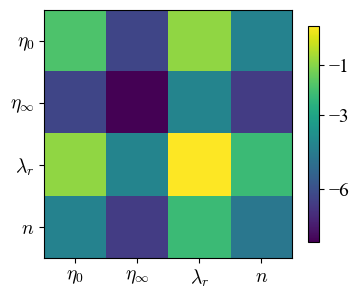

In [139]:
# fit log(rheodata) to Carreau model with parameter bounds
popt, pcov = curve_fit(Carreau_log,
                       np.log(rheodata['XG shear rate']),
                       # np.array([4.47, 0.0019, 12.3, 0.305]),
                       np.log(rheodata['XG viscosity']),
                       # initial guess from Spriggs
                       np.array([popt2[0], 2e-3, popt2[1], popt2[2]]),
                       # constraints based on Spriggs +/- 10%
                       bounds=((popt2[0]*0.9, mu_DI, popt2[1]*0.9, 0),
                               (popt2[0]*1.1, mu_DI*3, popt2[1]*1.1, 0.5)),
                       verbose=2, xtol=1e-12, ftol=1e-12)

# fit log(rheodata) to Carreau-Yasuda model
# popt, pcov = curve_fit(Carreau_Yasuda_log,
#                        np.log(rheodata['XG shear rate']),
#                        # np.array([4.47, 0.0019, 12.3, 0.305]),
#                        np.log(rheodata['XG viscosity']),
#                        bounds=((mu_DI, mu_DI, 0, 0, 0),
#                                (np.mean(rheodata['XG viscosity'][0:10])*1.1, mu_DI*3, 20, 0.5, 1)),
#                        verbose=2, xtol=1e-12, ftol=1e-12)

# compute R^2 value
r_squared = r2_score(np.log(rheodata['XG viscosity']),
                     # [4.5,2e-3,18,0.36]
                     Carreau_log(np.log(rheodata['XG shear rate']), *popt))
print(f'R^2 = {r_squared:.4}')

# print least-squares best-fit values
print('eta_0, lambda_r, lambda_inf, n =', popt)
# one standard deviation errors on the parameters
perr = np.sqrt(np.diag(pcov))
print('                             +/-', perr)

# show coavariance (sensitivity) matrix for fitted parameters
plt.figure(figsize=(4, 4))
plt.imshow(np.log(np.sqrt(np.abs(pcov))))
plt.colorbar(shrink=0.7, ticks=[-9, -6, -3, -1])
plt.yticks([0, 1, 2, 3], 
           labels=[r'$\eta_0$', r'$\eta_\infty$', r'$\lambda_r$', r'$n$'])
plt.xticks([0, 1, 2, 3], 
           labels=[r'$\eta_0$', r'$\eta_\infty$', r'$\lambda_r$', r'$n$']);

Based on Carreau fit with $(\eta_0,\eta_\infty,\lambda_r,n) = (4.5,2\times10^{-3},18,0.36)$, $R^2 = 0.9788$ computed using non-log variables or $R^2 = 0.9969$ computed using log variables.


In [140]:
print(f' power-law consistency factor m from Carreau = {popt[0]*popt[2]**(popt[3]-1):.4g}')
print(f' power-law consistency factor m from Spriggs = {popt2[0]*popt2[1]**(popt2[2]-1):.4g}')

 power-law consistency factor m from Carreau = 0.7523
 power-law consistency factor m from Spriggs = 0.7371


Plot the 'rheogram'.

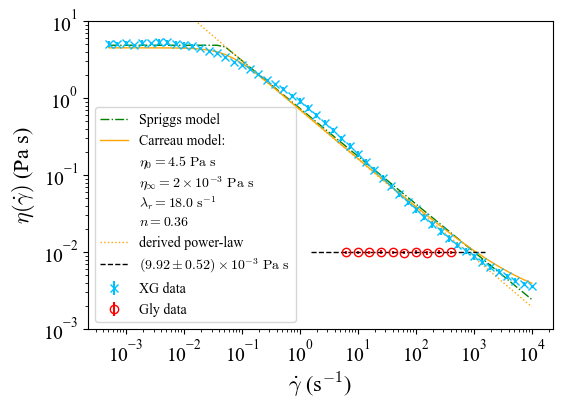

In [182]:
fig, ax1 = plt.subplots()
fig.set_figheight(4)
fig.set_figwidth(6)

ax1.set_xscale("log")
ax1.set_yscale("log")

# XG
ax1.errorbar(rheodata['XG shear rate'], rheodata['XG viscosity'], rheodata['XG viscosity err'],
             marker='x', ls='', color='deepskyblue', label='XG data')
ax1.errorbar(rheodata['Gly shear rate'], rheodata['Gly viscosity'], rheodata['Gly viscosity err'],
             marker='o', mfc='none', ls='', color='red', label='Gly data')

f = ticker.ScalarFormatter(useMathText=True)
f.set_powerlimits((-3, 3))

ax1.loglog(rheodata['XG shear rate'], Spriggs(rheodata['XG shear rate'], *popt2),
           ls='-.', color='green', lw=1, label="Spriggs model")
ax1.loglog(rheodata['XG shear rate'], Carreau(rheodata['XG shear rate'], 4.5, 2e-3, 18, 0.36),
           ls='-', color='orange', lw=1, label='Carreau model:')
ax1.loglog(np.nan, np.nan, ls='none',
           label=r'$\eta_0='+'{:.3}'.format(4.5)+r'~\mathrm{Pa~s}$'+'\n'
           + r'$\eta_\infty='
           + '{}'.format(f.format_data(float('{:.2e}'.format(2e-3))))
           + r'~\mathrm{Pa~s}$'+'\n'
           + r'$\lambda_r='+'{:.3}'.format(18.0)+r'~\mathrm{s}^{-1}$'+'\n'
           + r'$n='+'{:.2}$'.format(0.36))
plaw_x_plot_axis = np.logspace(-2, 4, endpoint=True)
ax1.loglog(plaw_x_plot_axis, 4.5*(18*plaw_x_plot_axis)**(0.36-1),
           ls=':', color='orange', lw=1, label='derived power-law')

# ax1.loglog(rheodata['XG shear rate'],Carreau(rheodata['XG shear rate'],*popt),
#            ls='-',color='black',lw=1, label='Carreau model:')
# ax1.loglog(np.nan,np.nan,ls='none',
#            label = '$\eta_0='+'{:.3}'.format(popt[0])+'~\mathrm{Pa~s}$\n'
#                   +'$\eta_\infty='+'{}'.format(f.format_data(float('{:.2e}'.format(popt[1]))))+'~\mathrm{Pa~s}$\n'
#                   +'$\lambda_r='+'{:.3}'.format(popt[2])+'~\mathrm{s}^{-1}$\n'
#                   +'$n='+'{:.2}$'.format(popt[3]))
#                   #+'\n'
#                   #+'$a='+'{:.2}$'.format(popt[4])
# ax1.loglog(plaw_x_plot_axis,popt[0]*(popt[2]*plaw_x_plot_axis)**(popt[3]-1),
#            ls=':',color='magenta',lw=1,label='derived power-law')


gly_x_plot_axis = np.logspace(0.2, 3.2, endpoint=True)
ax1.loglog(gly_x_plot_axis, mu_Gly*np.ones_like(gly_x_plot_axis),
           ls='--', color='black', lw=1,
           label=rf'$({mu_Gly*1e3:.3g}\pm{mu_Gly_err*1e3:.3g})\times 10^{{-3}}~\mathrm{{Pa~s}}$')

ax1.legend(loc='lower left')

ax1.set_xlabel(r'$\dot\gamma$ (s$^{-1}$)')
# ax1.set_xlim(5e-4,1e4)
ax1.set_ylabel(r'$\eta({\dot\gamma})$ (Pa s)')
ax1.set_ylim(1e-3, 1e1)

# Set ax major and minor tick locators with custom parameters to show
# all major and minor ticks despite the small figure height and the large
# range of x: the numticks argument must be a number at least one unit above
# the number of integer powers covering the range of y
nticks = 9
maj_loc = ticker.LogLocator(numticks=nticks)
min_loc = ticker.LogLocator(subs='all', numticks=nticks)
ax1.xaxis.set_major_locator(maj_loc)
ax1.xaxis.set_minor_locator(min_loc)

In [142]:
## save & download figure as PDF
# fig.savefig("fig2_icc.pdf",bbox_inches = 'tight')
# files.download("fig2_icc.pdf")

Define final rheological parameter values for use in the theory.

In [143]:
# zero-shear Newtonian viscosity for Carreau model
# from FIT Lab, 0.3% XG, Carreau fit
eta_0 = 4.5
# eta_0 = popt[0]

# inf-shear Newtonian viscosity for Carreau model
# from FIT Lab, 0.3% XG, Carreau fit
eta_inf = 2e-3
# eta_inf = popt[1]

# characteristic inverse shear rate for Carreau model
# from FIT Lab, 0.3% XG, Carreau fit
lambda_r = 18
# lambda_r = popt[2]

# power-law index for xanthan gum (< 1, shear-thinning)
# from FIT Lab, 0.3% XG, Carreau fit
n = 0.36
# n = popt[3]

# power-law consistency factor based on Carreau fit
m = eta_0 * lambda_r**(n-1)

# Carreau viscosity ratio
beta = eta_inf/eta_0

# per Jie's email 5/30/23
mu_Gly = 9.92 * (1e-3)
mu_Gly_err = 0.52 * (1e-3)

## ODE for the pressure: power-law regime

Next, we define the ODE for $p(z)$:
$$ \frac{dp_{\rm ch}}{dz} = -\frac{m}{h_0}\left\{\frac{[2^{1+1/n}(2+1/n)]q}{h_0^2w}\right\}^n \\
\times \left\{ \sum_{k=0}^{\infty}C_{k,n} \left[\frac{w^4}{24Bh_0}p_{\rm ch}(z)\right]^k
\left[1+\frac{8(t/w)^2}{\kappa(1-\nu_\mathrm{s})}\right]^{k} \right. \\
\left. \times \, 2^{-1-4k} \, \sqrt{\pi} \, \Gamma{(k+1)} \,\,{}_2\tilde{F}_1\left(\frac{1}{2},-k;\frac{3}{2}+k;\frac{1}{1+\frac{8(t/w)^2}{\kappa(1-\nu_\mathrm{s})}}\right)\right\}^{-n}, $$
which is Eq. (37) in Anand _et al._, numerically to obtain $p_{\rm ch}(z)$. Notice that the terms in  $\{ \cdots \}^{-n}$ are due to FSI.

For a Newtonian fluid (setting $n=1$ and $m=\eta_0\equiv\mu$), [Anand _et al._ (2019)](#References) showed (after much algebra) that the ODE above can be simplified and integrated directly to recoved the previous result from [Shidhore &amp; Christov (2018)](#References).

In [144]:
# number of terms to take in binomial expansion (don't change it)
kmax = 50

# right-hand side of the NNFSI dp/dz ODE
def odefun(z, p, h0, w, t_w, q, m, n, B, kappa, nu_s):
    c0 = m/h0 * ((2.0**(1/n+1) * (1.0/n+2.0))*q/(w*h0**2))**n
    c1 = 1 + 8*t_w**2 / (kappa*(1-nu_s))

    sum = 1
    # right-hand side of the NewtFSI dp/dz ODE, requires exactly 4 terms in sum!
    kmax2 = 4 if n == 1 else kmax
    for k in range(1, kmax2):
        Ckn = sc.gamma(3+1/n)/(sc.gamma(k+1)*sc.gamma(1/n-k+3))
        sum = sum + Ckn * ((w**4/(24*B*h0))*p)**k * c1**k \
                        * pow(2, -1-4*k) * np.sqrt(np.pi) * sc.gamma(k+1) \
                        * sc.hyp2f1(0.5, -k, 1.5+k, 1/c1)/sc.gamma(1.5+k)

    # no minus sign because we're integrating backwards from z=l to z=0
    dpdz = c0*pow(sum, -n)
    return dpdz

In [145]:
# for convenience, encapsulate ODE solving in a function
def p_channel(z, h0, w, t_w, q, m, n, B, kappa, nu_s, l):
    odesol = solve_ivp(odefun, [0, l], [1e-10], args=(h0, w, t_w, q, m, n, B, kappa, nu_s),
                       method='LSODA', rtol=1e-12, atol=1e-12, dense_output=True)
    # l-z because we're integrating backwards from z=l to z=0
    return odesol.sol(l-z)[0]

The rigid infinitely-wide channel solution for the pressure variation for the flow-controlled pressure-driven flow of a power-law fluid is easily found to be
\begin{align*}
p_{\rm rigid}(z) &= \frac{m}{h_0}\left\{\frac{[2^{1+1/n}(2+1/n)]q}{h_0^2w}\right\}^n  (\ell - z)\\
&= 2(4+2/n)^n \frac{\eta_{0}\ell}{\lambda_r h_0} Cu_\mathrm{ch}^{n} (1 - z/
\ell),
\end{align*}
where the Carreau number for a channel, $Cu_{\rm ch}$, will be defined [below](#Dimensionless_numbers_channel).

The Newtonian expression is obtained by setting $n=1$, in which case $\lambda_r$ cancel out of the second expression (or set $m=\eta_0$ in the first expression):
$$ p_{\rm rigid,\, Newt}(z) = 12\frac{\eta_0 \ell}{h_0} \frac{q}{h_0^2w} (1 - z/\ell) . $$

In [146]:
def p_rigid_channel(z, h0, w, q, m, n, l):
    return (m/h0)*pow(pow(2, 1+1/n)*(2+1/n)*q/(w*h0**2), n) * (l-z)

## Flow rate&ndash;pressure drop relation

### The pressure drop

#### Experimental data

*Updated Apr. 2023*

In [147]:
# check if need to define structures
if not ('q_expt' in vars()):
    # for experimental data
    q_expt, dp_expt, dp_expt_error = {}, {}, {}
    # and theoretical data
    q_vals, dp_vals, dp_vals_rigid, dp_vals_p, dp_vals_m = {}, {}, {}, {}, {}
    # and dimensionless numbers
    pc, alpha, Cu_expt, Re_expt = {}, {}, {}, {}

In [148]:
# DI soft, rectangular channel
q_expt['DI channel'] = np.linspace(1, 12, num=12) * (1e-6)/60
dp_expt['DI channel'] = np.array([0.10511, 0.10511, 0.11481, 0.13773, 0.21831,
                                  0.26318, 0.36171, 0.43514, 0.57391, 0.63182,
                                  0.69318, 0.73616]) * (1e3)
dp_expt_error['DI channel'] = np.array([0.06242, 0.05818, 0.08366, 0.07846,
                                        0.07431, 0.07462, 0.08616, 0.03173,
                                        0.05714, 0.03616, 0.08362, 0.06315]) * (1e3)

# 62% wt glycerin, soft rectangular channel
q_expt['Gly channel'] = np.linspace(1, 10, num=10) * (1e-6)/60
dp_expt['Gly channel'] = np.array([0.36942, 0.63568, 0.93472, 1.13342, 1.28186,
                                   1.39189, 1.52731, 1.71902, 1.84891, 1.99454]) * (1e3)
dp_expt_error['Gly channel'] = np.array([0.11481, 0.10137, 0.09345, 0.12735,
                                         0.09173, 0.11834, 0.13171, 0.11418,
                                         0.09173, 0.11714]) * (1e3)

# 0.3% XG, soft rectangular rectangular
q_expt['XG channel'] = np.array(
    [0.3, 0.5, 0.7, 0.9, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) * (1e-6)/60
dp_expt['XG channel'] = np.array([0.10127, 0.44632, 0.83614, 1.01351, 1.04171,
                                  1.21131, 1.31831, 1.37138, 1.47181, 1.58994,
                                  1.67383, 1.73513, 1.83617, 1.85714]) * (1e3)
dp_expt_error['XG channel'] = np.array([0.09131, 0.09138, 0.17318, 0.11138,
                                        0.1381, 0.09731, 0.10161, 0.11341,
                                        0.09311, 0.08416, 0.09371, 0.12191,
                                        0.09711, 0.11731]) * (1e3)

#### Theoretical prediction: power-law regime

Next, from the solution $p(z)$ to the ODE above we evaluate $\Delta p = p(0)$, which we are allowed to because we used $p(\ell)=0$ (gauge pressure) as a boundary condition. We repeat this step many times, for different $q$.\
[**Note:** This calculation assumes that the total streamwise length of the soft wall is $\ell$ as well!]

Note that the **rigid**, infinitely-wide channel solution for the pressure drop of a power-law fluid is
\begin{align*}
  \Delta p_{\rm rigid, ch} &= \frac{2m\ell}{h_0}\left\{\frac{(4+2/n)q}{h_0^2w}\right\}^n\\
  &= 2(4+2/n)^n \frac{\eta_{0}\ell}{\lambda_r h_0} Cu_\mathrm{ch}^{n},
\end{align*}
which is nonlinear (i.e., $\Delta p \propto q^n$ for $n\ne1$).

The the rigid Newtonian expression is obtained by setting $n=1$, in which case $\lambda_r$ cancel from the second expression (or, set $m=\eta_0$ in the first expression).

In [149]:
# input chosen flow rate range, refine near the origin where shape varies a lot
q_vals['channel'] = np.concatenate((np.linspace(0, 1.5, 35)*(1e-6)/60,
                                    np.linspace(1.5, 15, 25)*(1e-6)/60))

# pre-initialize arrays
dp_vals['XG channel'] = np.zeros_like(q_vals['channel'])
dp_vals_p['XG channel'] = np.zeros_like(q_vals['channel'])
dp_vals_m['XG channel'] = np.zeros_like(q_vals['channel'])
dp_vals['DI channel'] = np.zeros_like(q_vals['channel'])
dp_vals_p['DI channel'] = np.zeros_like(q_vals['channel'])
dp_vals_m['DI channel'] = np.zeros_like(q_vals['channel'])
dp_vals['Gly channel'] = np.zeros_like(q_vals['channel'])
dp_vals_p['Gly channel'] = np.zeros_like(q_vals['channel'])
dp_vals_m['Gly channel'] = np.zeros_like(q_vals['channel'])

In [150]:
## compute for corresponding theoretical pressure drops
## by integrating the ODE from the soft theory
for i in range(0,q_vals['channel'].size):
    q = q_vals['channel'][i]
    dp_vals['XG channel'][i] = p_channel(0,h0,w,t_w,q,m,n,B,kappa,nu_s,l['channel dp'])
    dp_vals['DI channel'][i] = p_channel(0,h0,w,t_w,q,mu_DI,1,B,kappa,nu_s,l['channel dp'])
    dp_vals['Gly channel'][i] = p_channel(0,h0,w,t_w,q,mu_Gly,1,B,kappa,nu_s,l['channel dp'])

    dp_vals_p['XG channel'][i] = p_channel(0,h0+h0_err,w,t_w,q,m,n,B,kappa,nu_s,l['channel dp'])
    dp_vals_p['DI channel'][i] = p_channel(0,h0+h0_err,w,t_w,q,mu_DI,1,B,kappa,nu_s,l['channel dp'])
    dp_vals_p['Gly channel'][i] = p_channel(0,h0+h0_err,w,t_w,q,mu_Gly-mu_Gly_err,1,B,kappa,nu_s,l['channel dp'])

    dp_vals_m['XG channel'][i] = p_channel(0,h0-h0_err,w,t_w,q,m,n,B,kappa,nu_s,l['channel dp'])
    dp_vals_m['DI channel'][i] = p_channel(0,h0-h0_err,w,t_w,q,mu_DI,1,B,kappa,nu_s,l['channel dp'])
    dp_vals_m['Gly channel'][i] = p_channel(0,h0-h0_err,w,t_w,q,mu_Gly+mu_Gly_err,1,B,kappa,nu_s,l['channel dp'])

In [151]:
## compute for corresponding theoretical pressure drops
## by using the rigid analytical solution
dp_vals_rigid['XG channel'] = p_rigid_channel(0,h0,w,q_vals['channel'],m,n,l['channel dp'])
dp_vals_rigid['DI channel'] = p_rigid_channel(0,h0,w,q_vals['channel'],mu_DI,1,l['channel dp'])
dp_vals_rigid['Gly channel'] = p_rigid_channel(0,h0,w,q_vals['channel'],mu_Gly,1,l['channel dp'])

##### Weakly deformable channel

Also, consider the case $w^4/(24Bh_0) \ll p_c$, for a suitable characteristic flow-based pressure scale $p_c$. Then, the right-hand side of the ODE above can be approximated as
$$ \frac{dp}{dz} \simeq -\frac{\Delta p_{\rm rigid, ch}}{\ell} \left( 1 - \frac{w^4}{24Bh_0}\, (2n+1)
 \frac{1}{15\times8} \left\{ 5 \left[1+\frac{8(t/w)^2}{\kappa(1-\nu_\mathrm{s})}\right] - 1 \right\}  p(z) \right), $$
which can be directly integrated to find:
$$ \Delta p \simeq \Delta p_{\rm rigid, ch} \Bigg( 1 -  \frac{w^4}{24 Bh_0} \frac{(2n+1)}{240} \Delta p_{\rm rigid, ch} \left\{ 5 \left[1+\frac{8(t/w)^2}{\kappa(1-\nu_\mathrm{s})}\right] - 1 \right\} \Bigg).$$

In [152]:
def dp_correction_channel(h0, w, t_w, q, m, n, B, kappa, nu_s, l):
    return p_rigid_channel(0, h0, w, q, m, n, l)*(1 - w**4/(24*B*h0)*(2*n+1)/240
                                                  * p_rigid_channel(0, h0, w, q, m, n, l)
                                                  * (5*(1+8*t_w**2/(kappa*(1-nu_s))) - 1))

<a name="Dimensionless_numbers_channel"></a>
### Dimensionless quantities

Now, we calculate the ranges of the dimensionless numbers for the experimental data
\begin{align*}
    \text{Carreau \#}:\qquad Cu_{\rm ch} &= \frac{\lambda_r q}{h_0^2 w},\\
    \text{NN FSI \#}:\qquad \alpha_{\rm ch} &= \underbrace{\left(\frac{q}{h_0^2 w}\right)^n\left(\frac{m \ell}{h_0}\right)}_{=p_c~\text{for power-law model}}\left(\frac{w^4}{B h_0}\right)\\
    &= \left(\frac{\lambda_r q}{h_0^2 w}\right)^n\left(\frac{\eta_0 \ell/\lambda_r h_0}{B h_0/w^4}\right)
    \\
    &= Cu_{\rm ch}^{n-1}\underbrace{\left(\frac{w^3 q \eta_0 \ell}{h_0^4 B}\right)}_{=\alpha_{\rm Newt, ch}},\\
    \text{NN reduced Reynolds \#}:\qquad \epsilon Re_{\rm ch} &= \left(\frac{h_0}{\ell}\right)\left(\frac{\rho q^{2-n} h_0^{2n-2} w^{n-2}}{m}\right),\\
    &= \frac{\rho q h_0}{\eta_0 w \ell} Cu_{\rm ch}^{1-n}.
\end{align*}

In [153]:
# characteristic pressure scale, for FLOW-CONTROLLED regime
pc['XG channel'] = ((q_expt['XG channel']/(h0**2 * w)) ** n) * (m*l['channel']/h0)
pc['DI channel'] = (q_expt['DI channel']/(h0**2 * w)) * (mu_DI*l['channel']/h0)
pc['Gly channel'] = (q_expt['Gly channel']/(h0**2 * w)) * (mu_Gly*l['channel']/h0)

# FSI number for a plate model

alpha['DI channel q'] = w**4 * pc['DI channel']/(B*h0)
print(' Range of   DI FSI number alpha based on q is',
      '{:.6}'.format(np.min(alpha['DI channel q'])),
      'to', '{:.6}'.format(np.max(alpha['DI channel q'])))

alpha['Gly channel q'] = w**4 * pc['Gly channel']/(B*h0)
print(' Range of  Gly FSI number alpha based on q is',
      '{:.6}'.format(np.min(alpha['Gly channel q'])),
      'to', '{:.6}'.format(np.max(alpha['Gly channel q'])))

alpha['XG channel q'] = w**4 * pc['XG channel']/(B*h0)
print(' Range of plaw FSI number alpha based on q is',
      '{:.6}'.format(np.min(alpha['XG channel q'])),
      'to', '{:.6}'.format(np.max(alpha['XG channel q'])), '\n')

# alpha['XG channel dp'] = w**4 * dp_expt['XG channel']/(B*h0)
# print(' Range of NN FSI number alpha based on dp is',
#       '{:.6}'.format(np.min(alpha['XG channel dp'])),
#       'to','{:.6}'.format(np.max(alpha['XG channel dp'])),'\n')

# Carreau number
Cu_expt['channel q'] = lambda_r*q_expt['XG channel']/(w * h0**2)
print(' Range of Cu based on q  is',
      '{:.6}'.format(np.min(Cu_expt['channel q'])),
      'to', '{:.6}'.format(np.max(Cu_expt['channel q'])))

# Cu_expt['channel dp'] = dp_expt['XG channel']*lambda_r/eta_0 * h0/l['channel dp']
# print(' Range of Cu based on dp is',
#       '{:.6}'.format(np.min(Cu_expt['channel dp'])),
#       'to','{:.6}'.format(np.max(Cu_expt['channel dp'])))

Cu_c = (eta_inf/eta_0)**(1/(n-1))
print(f' Cu critical for transition away from power-law is {Cu_c:.6g}\n')

# Newtonian Reynolds number based on flow rate
Re_expt['Gly channel q'] = h0/l['channel dp'] * rho_Gly*q_expt['Gly channel']/(mu_Gly*w)
print(' Range of reduced Gly Re based on  q is',
      '{:.4}'.format(np.min(Re_expt['Gly channel q'])),
      'to', '{:.4}'.format(np.max(Re_expt['Gly channel q'])))

# Power-law Reynolds number based on flow rate
# Re_expt['XG channel q'] = eps['channel'] * rho_XG*q_expt['XG channel']**(2-n)*h0**(2*n-2)*w**(n-2)/m
Re_expt['XG channel q'] = rho_XG*q_expt['XG channel']*h0 / (eta_0*w*l['channel dp'])*Cu_expt['channel q']**(1-n)
print(' Range of reduced plaw Re based on q is',
      '{:.4}'.format(np.min(Re_expt['XG channel q'])),
      'to', '{:.4}'.format(np.max(Re_expt['XG channel q'])))

 Range of   DI FSI number alpha based on q is 1.27419 to 15.2903
 Range of  Gly FSI number alpha based on q is 12.64 to 126.4
 Range of plaw FSI number alpha based on q is 45.873 to 162.104 

 Range of Cu based on q  is 288.0 to 9600.0
 Cu critical for transition away from power-law is 172896

 Range of reduced Gly Re based on  q is 0.003231 to 0.03231
 Range of reduced plaw Re based on q is 8.012e-05 to 0.02519


### The $q$&ndash;$\Delta p$ plot

 channel with t = 0.48 mm, E = 0.92 MPa


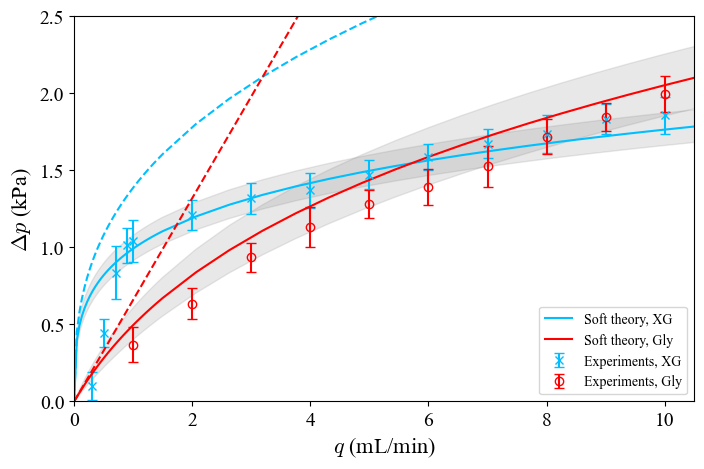

In [154]:
fig, ax1 = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1.set_xlabel(r'$q$ (mL/min)')
ax1.set_xlim(0, 10.5)
ax1.set_ylabel(r'$\Delta p$ (kPa)')
ax1.set_ylim(0, 2.5)

# XG
ax1.fill_between(q_vals['channel']*60/1e-6, dp_vals_p['XG channel']*1e-3, dp_vals_m['XG channel']*1e-3,
                 alpha=0.175, color='gray')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals['XG channel']*1e-3,
         '-', color='deepskyblue', label='Soft theory, XG')
ax1.errorbar(q_expt['XG channel']*60/1e-6, dp_expt['XG channel']*1e-3, 
             yerr=dp_expt_error['XG channel']*1e-3,
             marker='x', ls='', color='deepskyblue', capsize=3.5, label='Experiments, XG')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals_rigid['XG channel']*1e-3,
         '--', color='deepskyblue')

# only valid for \tilde{\alpha} \ll 1
# ax1.plot(q_vals['channel']*60/1e-6,dp_correction_channel(h0,w,t_w,q_vals['channel'],m,n,B,kappa,nu_s,l['channel dp'])*1e-3,
#          '-.',color='deepskyblue',label=r'Soft theory, XG, $\tilde{\alpha}\ll1$')

# DI water
# ax1.fill_between(q_vals['channel']*60/1e-6,dp_vals_p['DI channel']*1e-3,dp_vals_m['DI channel']*1e-3,
#                  alpha=0.175,color='gray')
# ax1.plot(q_vals['channel']*60/1e-6,dp_vals['DI channel']*1e-3,
#          '-',color='seagreen',label='Soft theory, DI')
# ax1.errorbar(q_expt['DI channel']*60/1e-6,dp_expt['DI channel']*1e-3,yerr=dp_expt_error['DI channel']*1e-3,
#              marker='*',ls='',color='seagreen',capsize=3.5,label='Experiments, DI')
# ax1.plot(q_vals['channel']*60/1e-6,dp_vals_rigid['DI channel']*1e-3,
#          '--',color='seagreen')

# Gly
ax1.fill_between(q_vals['channel']*60/1e-6, dp_vals_p['Gly channel']*1e-3, dp_vals_m['Gly channel']*1e-3,
                 alpha=0.175, color='gray')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals['Gly channel']*1e-3,
         '-', color='red', label='Soft theory, Gly')
ax1.errorbar(q_expt['Gly channel']*60/1e-6, dp_expt['Gly channel']*1e-3, 
             yerr=dp_expt_error['Gly channel']*1e-3,
             marker='o', mfc='none', ls='', color='red', capsize=3.5, label='Experiments, Gly')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals_rigid['Gly channel']*1e-3,
         '--', color='red')

ax1.legend()

print(f' channel with t = {t*1e3:.2f} mm, E = {E["channel"]*1e-6:.2f} MPa')

In [155]:
## save & download figure as PDF
# fig.savefig("q_dp_GlyXG_channel.pdf",bbox_inches = 'tight')
# files.download("q_dp_GlyXG_channel.pdf")

# Axisymmetric microtube extruded from large block of compliant material

## Parameters

All in SI units using MKS.

### Geometry and solid material properties

Geometric parameters for experiments.

Material properties of PDMS are measured after it is manufactured.

In [156]:
# undeformed tube radius from Wang et al.
# a0 = 25 * (1e-6)
# from FIT Lab
a0, a0_err = {}, {}
a0['tube CH10'] = 0.09 * (1e-3) / 2
a0_err['tube CH10'] = 0.002 * (1e-3) / 2
a0['tube CH20'] = 0.084 * (1e-3) / 2
a0_err['tube CH20'] = 0.005 * (1e-3) / 2

# total length of the deformable (section of the) tube
# from Anand et al.
# l['tube'] = 2.5 * (1e-3)
# from FIT Lab
l['tube dp'] = 23 * (1e-3)  # +/- 0.2
l['tube'] = 28.7 * (1e-3)  # +/- 0.2

# locations at which the pressure drop is measured
z1, z2 = {}, {}
z1['tube'] = 1.4 * (1e-3)  # +/- 0.1
z2['tube'] = z1['tube'] + l['tube dp']

# Young's modulus, on the order of 1 MPa
# from FIT Lab
E['tube CH10'] = 1.58 * (1e6)
E_err['tube CH10'] = 0.08 * (1e6)
E['tube CH20'] = 0.62 * (1e6)
E_err['tube CH20'] = 0.05 * (1e6)

# Poisson ratio, close to 0.5 for PDMS
# from FIT Lab, CH30 is 0.48, CH10 is 0.46
# using the average
nu_s = 0.47

# derived elastic shear modulus
G_s, G_s_p, G_s_m = {}, {}, {}
G_s['tube CH10'] = E['tube CH10']/(2*(1 + nu_s))
G_s['tube CH20'] = E['tube CH20']/(2*(1 + nu_s))
G_s_p['tube CH10'] = (E['tube CH10']+E_err['tube CH10'])/(2*(1 + nu_s))
G_s_p['tube CH20'] = (E['tube CH20']+E_err['tube CH20'])/(2*(1 + nu_s))
G_s_m['tube CH10'] = (E['tube CH10']-E_err['tube CH10'])/(2*(1 + nu_s))
G_s_m['tube CH20'] = (E['tube CH20']-E_err['tube CH20'])/(2*(1 + nu_s))

In [157]:
# pick only one tube geometry to plot
geom = 'tube CH10'

Geometric ratios (dimensionless)

In [158]:
eps['tube CH10'] = a0['tube CH10']/l['tube']
eps['tube CH20'] = a0['tube CH20']/l['tube']
print(f' streamwise aspect ratio, epsilon for CH10 = {eps["tube CH10"]:.4g}')
print(f' streamwise aspect ratio, epsilon for CH20 = {eps["tube CH20"]:.4g}')

 streamwise aspect ratio, epsilon for CH10 = 0.001568
 streamwise aspect ratio, epsilon for CH20 = 0.001463


### Fluid's thermophysical properties

In [159]:
# using same values defined above for microchannel

## Solution for the pressure: power-law regime

Combining the results of [Wang _et al._ (2022)](#References) and [Christov (2022)](#References), the solution for the pressure of a power-law fluid in a deformable microtube is
\begin{align*}
  p_{\rm tb}(z) &= 2G \left\{\left[ 1 + (2+3n) (3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}G}\right)\left(1-z/\ell\right)\right]^{\frac{1}{2+3n}}-1\right\}\\
  &= \frac{\eta_0\ell}{\lambda_r a_0} \frac{Cu_\mathrm{tb}^n}{\alpha_\mathrm{tb}} \left\{\left[ 1 + (2+3n) 2 (3+1/n)^n \alpha_\mathrm{tb} (1-z/\ell)\right]^{1/(2+3n)}-1\right\},
\end{align*}
where $G=E/[2(1+\nu_s)]$ is the elastic shear modulus, and the Carreau number for a tube, $Cu_{\rm tb}$, and the FSI number for a tube, $\alpha_{\rm tb}$, will be defined [below](#Dimensionless_numbers_tube).

The Newtonian expression from [Wang _et al._ (2022)](#References) is recovered by setting $n=1$, in which case $\lambda_r$ cancel out of the second expression (or set $m=\eta_0$ in the first expression).

In [160]:
def p_tube(z, a, q, m, n, G, l):
    return 2*G * (pow(1 + (3+1/n)**n * (2+3*n)
                      * (m*q**n / (np.pi**n * a**(1+3*n) * G))
                      * (l-z), 1/(2+3*n))
                  - 1)

The corresponding **rigid** tube expression is obtained by taking the limit as $\alpha_{\rm tb}\to0$ (infinitely stiff/undeformable tube, "$G\to\infty$"), which can be done either with L'H&ocirc;pital's rule or a Taylor series, obtaining:
\begin{align*}
  p_{\rm rigid,tb}(z) &= 2(3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}}\right)\left(1-z/\ell\right)\\
  &= 2(3+1/n)^n \frac{\eta_0\ell}{\lambda_r a_0} Cu_\mathrm{tb}^n (1-z/\ell),
\end{align*}
and the Newtonian expression is obtained by setting $n=1$, in which case $\lambda_r$ cancel out of the second expression (or set $m=\eta_0$ in the first expression).


In [161]:
def p_rigid_tube(z, a, q, m, n, l):
    return 2*(3+1/n)**n * (m*q**n / (np.pi**n * a**(1+3*n))) * (l-z)

## Flow rate&ndash;pressure drop relation

### The pressure drop

#### Experimental data

*Updated May 2023*

In [162]:
# check if need to define structures
if 'q_expt' not in vars():
    # for experimental data
    q_expt, dp_expt, dp_expt_error = {}, {}, {}
    # and theoretical data
    q_vals, dp_vals, dp_vals_rigid, dp_vals_p, dp_vals_m = {}, {}, {}, {}, {}
    # and dimensionless numbers
    pc, alpha, Cu_expt, Re_expt = {}, {}, {}, {}

In [163]:
# convert from *micro*L/min to m^3/s
q_expt['XG tube CH10'] = np.array([5, 10, 15, 20, 30, 40, 50]) * (1e-9)/60
dp_expt['XG tube CH10'] = np.array([11.3291, 14.1129, 15.91831, 18.21813,
                                    20.1852, 21.9481, 24.95181]) * (1e3)
dp_expt_error['XG tube CH10'] = np.array([0.41218, 0.45381, 0.97312, 0.96842,
                                          0.81371, 0.91844, 1.38231]) * (1e3)

q_expt['Gly tube CH10'] = np.array([1, 2, 5, 10, 20, 40, 50]) * (1e-9)/60
dp_expt['Gly tube CH10'] = np.array([1.50419, 3.07931, 9.93797, 19.33105,
                                     37.17602, 71.22415, 89.28282]) * (1e3)
dp_expt_error['Gly tube CH10'] = np.array([0.27579, 0.62949, 1.47548, 1.24591,
                                           1.15922, 1.24481, 1.53481]) * (1e3)
# convert from *micro*L/min to m^3/s
q_expt['XG tube CH20'] = np.array([0.2, 0.4, 0.6, 0.8, 1, 2, 4, 6, 8, 10]) * (1e-9)/60
dp_expt['XG tube CH20'] = np.array([1.018496865, 2.1038779, 2.772477686,
                                    3.479668959, 4.518621863, 6.365828687,
                                    7.969860865, 9.768086987, 10.96821062,
                                    11.96851861]) * (1e3)
dp_expt_error['XG tube CH20'] = np.array([0.231441155, 0.353564131, 0.41315566,
                                          0.561391248, 0.947197819, 0.917813789,
                                          1.113491044, 1.457819382, 1.137137131,
                                          1.238138914]) * (1e3)

q_expt['Gly tube CH20'] = np.array([1, 2, 5, 10, 20, 40, 50]) * (1e-9)/60
dp_expt['Gly tube CH20'] = np.array([1.10381, 2.91701, 9.74819, 18.73181,
                                     35.18191, 64.1831, 79.93984]) * (1e3)
dp_expt_error['Gly tube CH20'] = np.array([0.18411, 0.53181, 1.12911, 1.39148,
                                           1.59181, 1.19481, 1.29173]) * (1e3)

#### Theoretical prediction: power-law regime


Now, since we have exact solutions for $p_{\rm tb}(z)$, we can easily construct an arbitrary pressure drop as $p_{\rm tb}(z_1) - p_{\rm tb}(z_2)$. If we again we use $p(\ell)=0$ (gauge pressure) as a boundary condition, then 
\begin{align*}
  \Delta p_{\rm tb} = p(0) - p(\ell) &= 2G \left\{\left[ 1 + (2+3n) (3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}G}\right)\right]^{\frac{1}{2+3n}}-1\right\}\\
  &= \frac{\eta_0\ell}{\lambda_r a_0} \frac{Cu_\mathrm{tb}^n}{\alpha_\mathrm{tb}} \left\{\left[ 1 + (2+3n) 2(3+1/n)^n \alpha_\mathrm{tb} \right]^{1/(2+3n)}-1\right\},
\end{align*}
[**Note:** This calculation assumes that the total streamwise length of the soft wall is $\ell$ as well!]


So, for the **rigid** tube, the pressure drop of a power-law fluid is
\begin{align*}
  \Delta p_{\rm rigid, tb} &= 2(3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}}\right)\\
  &= 2(3+1/n)^n \frac{\eta_0\ell}{\lambda_r a_0} Cu_\mathrm{tb}^n,
\end{align*}
which is nonlinear for (i.e., $\Delta p \propto q^n$ for $n\ne1$).

And the rigid Newtonian expression is obtained is obtained by setting $n=1$, in which case $\lambda_r$ cancel out of the second expression (or set $m=\eta_0$ in the first expression).

In [164]:
# input chosen flow rate range, refine near the origin where shape varies a lot
# in *micro* liters
q_vals['tube'] = np.concatenate((np.linspace(0,2.5,50)*(1e-9)/60,
                                 np.linspace(2.5,10,50)*(1e-9)/60,
                                 np.linspace(10,1000,100)*(1e-9)/60))

dp_vals['XG '+geom] = p_tube(z1['tube'],a0[geom],q_vals['tube'],m,n,G_s[geom],l['tube']) \
                      - p_tube(z2['tube'],a0[geom],q_vals['tube'],m,n,G_s[geom],l['tube'])
dp_vals_p['XG '+geom] = p_tube(z1['tube'],a0[geom]+a0_err[geom],q_vals['tube'],m,n,G_s[geom],l['tube']) \
                        - p_tube(z2['tube'],a0[geom]+a0_err[geom],q_vals['tube'],m,n,G_s[geom],l['tube'])
dp_vals_m['XG '+geom] = p_tube(z1['tube'],a0[geom]-a0_err[geom],q_vals['tube'],m,n,G_s[geom],l['tube']) \
                        - p_tube(z2['tube'],a0[geom]-a0_err[geom],q_vals['tube'],m,n,G_s[geom],l['tube'])

# dp_vals['DI '+geom] = p_tube(0,a0[geom],q_vals['tube'],mu_DI,1,G_s[geom],l['tube'])
# dp_vals_p['DI '+geom] = p_tube(0,a0[geom]+a0_err[geom],q_vals['tube'],mu_DI,1,G_s[geom],l['tube'])
# dp_vals_m['DI '+geom] = p_tube(0,a0[geom]-a0_err[geom],q_vals['tube'],mu_DI,1,G_s[geom],l['tube'])

dp_vals['Gly '+geom] = p_tube(z1['tube'],a0[geom],q_vals['tube'],mu_Gly,1,G_s[geom],l['tube']) \
                       - p_tube(z2['tube'],a0[geom],q_vals['tube'],mu_Gly,1,G_s[geom],l['tube'])
dp_vals_p['Gly '+geom] = p_tube(z1['tube'],a0[geom]+a0_err[geom],q_vals['tube'],mu_Gly-mu_Gly_err,1,G_s_p[geom],l['tube']) \
                         - p_tube(z2['tube'],a0[geom]+a0_err[geom],q_vals['tube'],mu_Gly-mu_Gly_err,1,G_s_p[geom],l['tube'])
dp_vals_m['Gly '+geom] = p_tube(z1['tube'],a0[geom]-a0_err[geom],q_vals['tube'],mu_Gly+mu_Gly_err,1,G_s_m[geom],l['tube']) \
                         - p_tube(z2['tube'],a0[geom]-a0_err[geom],q_vals['tube'],mu_Gly+mu_Gly_err,1,G_s_m[geom],l['tube'])

dp_vals_rigid['XG tube']= p_rigid_tube(z1['tube'],a0[geom],q_vals['tube'],m,n,l['tube']) \
                          - p_rigid_tube(z2['tube'],a0[geom],q_vals['tube'],m,n,l['tube'])
dp_vals_rigid['DI tube'] = p_rigid_tube(z1['tube'],a0[geom],q_vals['tube'],mu_DI,1,l['tube']) \
                           - p_rigid_tube(z2['tube'],a0[geom],q_vals['tube'],mu_DI,1,l['tube'])
dp_vals_rigid['Gly tube'] = p_rigid_tube(z1['tube'],a0[geom],q_vals['tube'],mu_Gly,1,l['tube']) \
                            - p_rigid_tube(z2['tube'],a0[geom],q_vals['tube'],mu_Gly,1,l['tube'])

##### Weakly deformable tube

Also, consider $\alpha \ll 1$ (see below for defintion and discussion), then pressure drop for the deformable tube above can be approximated as
$$ \Delta p = 2G \left\{\left[ 1 + (2+3n) (3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}G}\right)\right]^{\frac{1}{2+3n}}-1\right\}
\\ \simeq 2(3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}}\right) \Bigg[ 1 -  \left[\frac{n}{2} (3+1/n) \right] (3+1/n)^n \left(\frac{m q^n \ell}{\pi^n a_0^{1+3n}G}\right) \Bigg].$$

The Newtonian case is obtained by setting $n=1$ and $m=\eta_0\equiv\mu$:
$$ \Delta p_{\rm Newt} \simeq 8\left(\frac{\mu q \ell}{\pi a_0^4}\right)\left[ 1 - 8 \left(\frac{\mu q \ell}{\pi a_0^4 G}\right) \right].  $$

In [165]:
def dp_correction_tube(a, q, m, n, G, l):
    return p_rigid_tube(0, a, q, m, n, l)*(1 - (n/4)*(3+1/n)/G
                                           * p_rigid_tube(0, a, q, m, n, l))

<a name="Dimensionless_numbers_tube"></a>
### Dimensionless numbers

Now, we calculate the ranges of the dimensionless numbers for the experimental data
\begin{align*}
\text{Carreau \#}:\qquad Cu_{\rm tb} &= \frac{\lambda_r q}{\pi a_0^3},\\
\text{power-law FSI \#}:\qquad \alpha &= \underbrace{\left(\frac{q}{\pi a_0^3}\right)^n\left(\frac{m \ell}{a_0}\right)}_{=p_c~\text{for power-law model}}\left(\frac{\mathcal{C}}{a_0}\right)\\
&= \left(\frac{\lambda_r q}{\pi a_0^3}\right)^n\left(\frac{\eta_0 \ell/\lambda_r a_0}{2G}\right)
\\
&= Cu_{\rm tb}^{n-1}\underbrace{\left(\frac{q \eta_0 \ell}{2 \pi a_0^4 G}\right)}_{=\alpha_{\rm Newt, tb}},\\
\text{power-law reduced Reynolds \#}:\qquad \epsilon Re_{\rm tb} &= \left(\frac{a_0}{\ell}\right)\left(\frac{\rho q^{2-n} a_0^{3n-4} \pi^{n-2}}{m}\right)\\
&= \frac{\rho q}{\eta_0\pi \ell} Cu_{\rm tb}^{1-n}.
\end{align*}

In [166]:
# characteristic pressure scale, for FLOW-CONTROLLED regime
# pc['DI '+geom] = ( q_expt['DI '+geom]/(a0[geom]**3 * np.pi) ) * ( mu_DI*l['tube']/a0[geom] )
pc['Gly '+geom] = (q_expt['Gly '+geom]/(a0[geom]**3 * np.pi)) * (mu_Gly*l['tube']/a0[geom])
pc['XG '+geom] = ((q_expt['XG '+geom]/(a0[geom]**3 * np.pi)) ** n) * (m*l['tube']/a0[geom])

# compliance constant of the extruded microtube
calC = a0[geom]/(2*G_s[geom])

# FSI number
# alpha['DI tube q'] = pc['DI '+geom]/(a0[geom] / calC)
# print(' Range of DI FSI number alpha based on q is',
#       '{:.6}'.format(np.min(alpha['DI tube q'])),
#       'to','{:.6}'.format(np.max(alpha['DI tube q'])))

alpha['Gly tube q'] = pc['Gly '+geom]/(a0[geom] / calC)
print(' Range of  Gly FSI number alpha based on q is',
      '{:.6}'.format(np.min(alpha['Gly tube q'])),
      'to', '{:.6}'.format(np.max(alpha['Gly tube q'])))

alpha['XG tube q'] = pc['XG '+geom]/(a0[geom] / calC)
print(' Range of plaw FSI number alpha based on q is',
      '{:.6}'.format(np.min(alpha['XG tube q'])),
      'to', '{:.6}'.format(np.max(alpha['XG tube q'])), '\n')

# Carreau number
Cu_expt[geom+' q'] = lambda_r*q_expt['XG '+geom]/(np.pi * a0[geom]**3)
print(' Range of Cu based on q  is',
      '{:.6}'.format(np.min(Cu_expt[geom+' q'])),
      'to', '{:.6}'.format(np.max(Cu_expt[geom+' q'])))

# Cu_expt[geom+' dp'] = dp_expt['XG '+geom]*lambda_r/eta_0 * a0[geom]/l['tube dp']
# print(' Range of Cu based on dp is',
#       '{:.6}'.format(np.min(Cu_expt[geom+' dp'])),
#       'to','{:.6}'.format(np.max(Cu_expt[geom+' dp'])))

Cu_c = (eta_inf/eta_0)**(1/(n-1))
print(' Cu critical for transition away from power-law is',
      '{:.6}'.format(Cu_c), '\n')

# Newtonian Reynolds number based on flow rate
Re_expt['Gly '+geom+' q'] = a0[geom]/l['tube'] * rho_Gly*q_expt['Gly '+geom]/(np.pi*a0[geom]*mu_Gly)
print(' Range of reduced  Gly Re based on q is',
      '{:.6}'.format(np.min(Re_expt['Gly '+geom+' q'])),
      'to', '{:.6}'.format(np.max(Re_expt['Gly '+geom+' q'])))

# Power-law Reynolds number based on flow rate
# Re_expt['XG '+geom+' q'] = eps[geom] * rho_XG*q_expt['XG '+geom]**(2-n)*a0[geom]**(3*n-4)*np.pi**(n-2)/m
Re_expt['XG '+geom+' q'] = rho_XG*q_expt['XG '+geom] / \
    (eta_0*l['tube']*np.pi)*Cu_expt[geom+' q']**(1-n)
print(' Range of reduced plaw Re based on q is',
      '{:.6}'.format(np.min(Re_expt['XG '+geom+' q'])),
      'to', '{:.6}'.format(np.max(Re_expt['XG '+geom+' q'])))

 Range of  Gly FSI number alpha based on q is 0.000342691 to 0.0171345
 Range of plaw FSI number alpha based on q is 0.00323757 to 0.00741684 

 Range of Cu based on q  is 5239.67 to 52396.7
 Cu critical for transition away from power-law is 1.72896e+05 

 Range of reduced  Gly Re based on q is 1.8634e-05 to 0.000931698
 Range of reduced plaw Re based on q is 4.93093e-05 to 0.00215243


### The $q$&ndash;$\Delta p$ plot

tube CH10 with E = 1.58 MPa


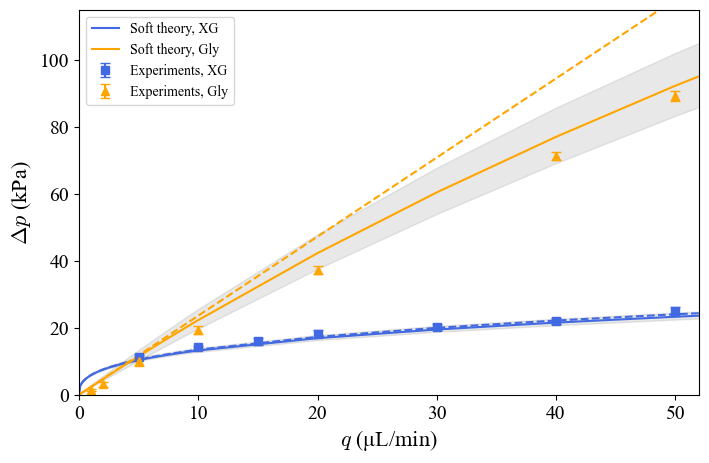

In [167]:
fig, ax1 = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1.set_xlabel(r'$q$ (μL/min)')
ax1.set_xlim(0, 52)
ax1.set_ylabel(r'$\Delta p$ (kPa)')
ax1.set_ylim(0, 115)

# XG
ax1.fill_between(q_vals['tube']*60/1e-9, dp_vals_p['XG '+geom]*1e-3, dp_vals_m['XG '+geom]*1e-3,
                 alpha=0.175, color='gray')
ax1.plot(q_vals['tube']*60/1e-9, dp_vals['XG '+geom]*1e-3,
         '-', color='royalblue', label='Soft theory, XG')
ax1.errorbar(q_expt['XG '+geom]*60/1e-9, dp_expt['XG '+geom]*1e-3,
             yerr=dp_expt_error['XG '+geom]*1e-3, marker='s',
             ls='', color='royalblue', capsize=3.5, label='Experiments, XG')
ax1.plot(q_vals['tube']*60/1e-9, dp_vals_rigid['XG tube']*1e-3,
         '--', color='royalblue')

# only valid for {\alpha} \ll 1
# ax1.plot(q_vals['tube']*60/1e-9,dp_correction_tube(a0[geom],q_vals['tube'],m,n,G_s[geom],l['tube dp'])*1e-3,
#          '-.',color='royalblue',label=r'Soft theory, XG, $\alpha\ll1$')

# Gly
ax1.fill_between(q_vals['tube']*60/1e-9, dp_vals_p['Gly '+geom]*1e-3, dp_vals_m['Gly '+geom]*1e-3,
                 alpha=0.175, color='gray')
ax1.plot(q_vals['tube']*60/1e-9, dp_vals['Gly '+geom]*1e-3,
         '-', color='orange', label='Soft theory, Gly')
ax1.errorbar(q_expt['Gly '+geom]*60/1e-9, dp_expt['Gly '+geom]*1e-3, 
             yerr=dp_expt_error['Gly '+geom]*1e-3,
             marker='^', ls='', color='orange', capsize=3.5, label='Experiments, Gly')
ax1.plot(q_vals['tube']*60/1e-9, dp_vals_rigid['Gly tube']*1e-3,
         '--', color='orange')

# only valid for {\alpha} \ll 1
# ax1.plot(q_vals['tube']*60/1e-9,dp_correction_tube(a0[geom],q_vals['tube'],mu_Gly,1,G_s[geom],l['tube dp'])*1e-3,
#          '-.',color='orange',label=r'Soft theory, Gly, $\alpha\ll1$')

ax1.legend()

print(str(geom)+f' with E = {E[geom]*1e-6:.2f} MPa')

# Combined plots

## $q$&ndash;$\Delta p$

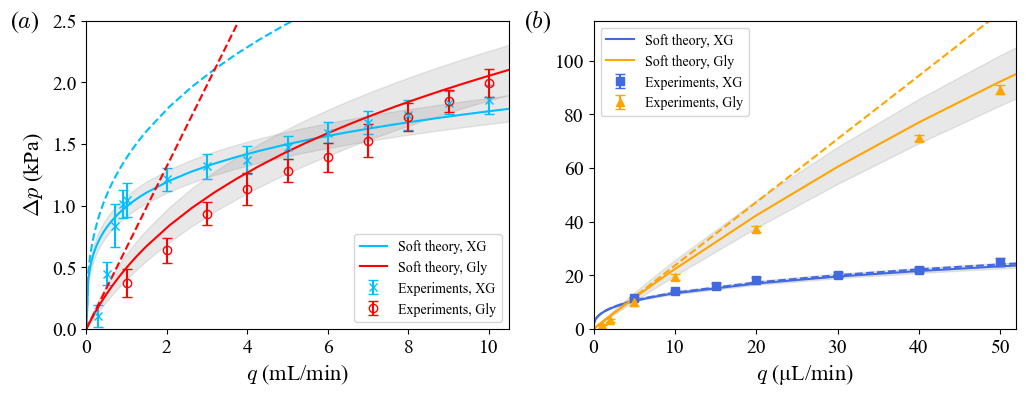

In [168]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figheight(4)
fig.set_figwidth(12)

# (a) channel
ax1.set_xlabel(r'$q$ (mL/min)')
ax1.set_xlim(0, 10.5)
ax1.set_ylabel(r'$\Delta p$ (kPa)')
ax1.set_ylim(0, 2.5)

trans = mtransforms.ScaledTranslation(-55/72, -5/72, fig.dpi_scale_trans)
ax1.text(0.0, 1.0, r'($a$)', fontsize='xx-large', transform=ax1.transAxes + trans)

# XG
ax1.fill_between(q_vals['channel']*60/1e-6, dp_vals_p['XG channel']*1e-3, dp_vals_m['XG channel']*1e-3,
                 alpha=0.175, color='gray')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals['XG channel']*1e-3,
         '-', color='deepskyblue', label='Soft theory, XG')
ax1.errorbar(q_expt['XG channel']*60/1e-6, dp_expt['XG channel']*1e-3, yerr=dp_expt_error['XG channel']*1e-3,
             marker='x', ls='', color='deepskyblue', capsize=3.5, label='Experiments, XG')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals_rigid['XG channel']*1e-3,
         '--', color='deepskyblue')

# DI water
# ax1.fill_between(q_vals['channel']*60/1e-6,dp_vals_p['DI channel']*1e-3,dp_vals_m['DI channel']*1e-3,
#                  alpha=0.175,color='gray')
# ax1.plot(q_vals['channel']*60/1e-6,dp_vals['DI channel']*1e-3,
#          '-',color='seagreen',label='Soft theory, DI')
# ax1.errorbar(q_expt['DI channel']*60/1e-6,dp_expt['DI channel']*1e-3,yerr=dp_expt_error['DI channel']*1e-3,
#              marker='*',ls='',color='seagreen',capsize=3.5,label='Experiments, DI')
# ax1.plot(q_vals['channel']*60/1e-6,dp_vals_rigid['DI channel']*1e-3,
#          '--',color='seagreen')

# Gly
ax1.fill_between(q_vals['channel']*60/1e-6, dp_vals_p['Gly channel']*1e-3, dp_vals_m['Gly channel']*1e-3,
                 alpha=0.175, color='gray')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals['Gly channel']*1e-3,
         '-', color='red', label='Soft theory, Gly')
ax1.errorbar(q_expt['Gly channel']*60/1e-6, dp_expt['Gly channel']*1e-3, yerr=dp_expt_error['Gly channel']*1e-3,
             marker='o', mfc='none', ls='', color='red', capsize=3.5, label='Experiments, Gly')
ax1.plot(q_vals['channel']*60/1e-6, dp_vals_rigid['Gly channel']*1e-3,
         '--', color='red')  # ,label='Rigid theory, Gly')

ax1.legend()

# (b) tube
ax2.set_xlabel(r'$q$ (μL/min)')
ax2.set_xlim(0, 52)
# ax2.set_ylabel(r'$\Delta p$ (kPa)')
ax2.set_ylim(0, 115)

trans = mtransforms.ScaledTranslation(-50/72, -5/72, fig.dpi_scale_trans)
ax2.text(0.0, 1.0, r'($b$)', fontsize='xx-large',
         transform=ax2.transAxes + trans)

# XG
ax2.fill_between(q_vals['tube']*60/1e-9, dp_vals_p['XG '+geom]*1e-3, dp_vals_m['XG '+geom]*1e-3,
                 alpha=0.175, color='gray')
ax2.plot(q_vals['tube']*60/1e-9, dp_vals['XG '+geom]*1e-3,
         '-', color='royalblue', label='Soft theory, XG')
ax2.errorbar(q_expt['XG '+geom]*60/1e-9, dp_expt['XG '+geom]*1e-3,
             yerr=dp_expt_error['XG '+geom]*1e-3, marker='s',
             ls='', color='royalblue', capsize=3.5, label='Experiments, XG')
ax2.plot(q_vals['tube']*60/1e-9, dp_vals_rigid['XG tube']*1e-3,
         '--', color='royalblue')

# Gly
ax2.fill_between(q_vals['tube']*60/1e-9, dp_vals_p['Gly '+geom]*1e-3, dp_vals_m['Gly '+geom]*1e-3,
                 alpha=0.175, color='gray')
ax2.plot(q_vals['tube']*60/1e-9, dp_vals['Gly '+geom]*1e-3,
         '-', color='orange', label='Soft theory, Gly')
ax2.errorbar(q_expt['Gly '+geom]*60/1e-9, dp_expt['Gly '+geom]*1e-3, yerr=dp_expt_error['Gly '+geom]*1e-3,
             marker='^', ls='', color='orange', capsize=3.5, label='Experiments, Gly')
ax2.plot(q_vals['tube']*60/1e-9, dp_vals_rigid['Gly tube']*1e-3,
         '--', color='orange')

ax2.legend();

In [169]:
## save & download figure
# fig.savefig("q_dp_all.pdf",bbox_inches = 'tight')
# files.download("q_dp_all.pdf")
# fig.savefig("fig3_4.pdf",bbox_inches = 'tight')
# files.download("fig3_4.pdf")

## $Cu$&ndash;$\alpha$

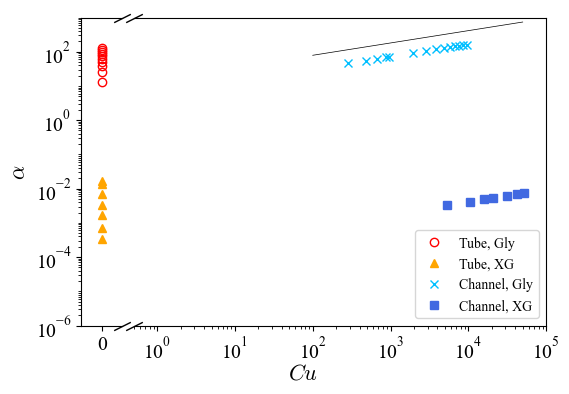

In [170]:
# following https://matplotlib.org/stable/gallery/subplots_axes_and_figures/broken_axis.html

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True,
                               gridspec_kw={'width_ratios': [0.1, 1]})
fig.set_figheight(4)
fig.set_figwidth(6)
fig.subplots_adjust(wspace=0.05)  # adjust space between axes

# channel data
ax2.loglog(Cu_expt['channel q'], alpha['XG channel q'],
           marker='x', ls='', color='deepskyblue',
           label='Channel, Gly')
ax1.plot(np.zeros_like(alpha['Gly channel q']), alpha['Gly channel q'],
         marker='o', mfc='none', ls='', color='red',
         label='Tube, Gly')

# tube data
ax2.loglog(Cu_expt['tube CH10 q'], alpha['XG tube q'],
           marker='s', ls='', color='royalblue',
           label='Channel, XG')
ax1.plot(np.zeros_like(alpha['Gly tube q']), alpha['Gly tube q'],
         marker='^', ls='', color='orange',
         label='Tube, XG')

# customize legend
fig.legend(loc='lower right',
           bbox_to_anchor=(0.89, 0.125),
           borderaxespad=0.1    # Small spacing around legend box
           # title='Experimental data:'
           )

# slope
xslopes = np.array([1e2, 1e3, 5e4])
yslopes = 15*np.array([1e2, 1e3, 5e4])**n
ax2.loglog(xslopes, yslopes, c='black', lw=0.5)

# zoom-in / limit the view and change the ticks
# ax1.set_xlim(e-1,1.1e-1)
ax1.set_xticks([0])

ax2.set_xlim(.5, 1e5)
ax2.set_xticks([1, 1e1, 1e2, 1e3, 1e4, 1e5])

ax1.set_ylabel(r'$\alpha$')
ax2.set_xlabel(r'$Cu$')
ax2.xaxis.set_label_coords(0.41, -0.125)

# add slanted lines where the axes break
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)

# coordinate ylims
ax1.set_ylim(1e-6, 1e3)
# ax2.set_yticks([1e-3,1e-1,1e1,1e3])
ax2.set_ylim(1e-6, 1e3)

# set ax major and minor tick locators with custom parameters
ax1.tick_params(axis='y', labelright=False, right=False)
y_major = ticker.LogLocator(base=10.0, numticks=6)
y_minor = ticker.LogLocator(
    base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10)
ax1.yaxis.set_minor_locator(y_minor)
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())

# hide the spines between ax1 and ax2
ax1.spines.right.set_visible(False)
ax2.spines.left.set_visible(False)
ax2.tick_params(axis='y', which='both', left=False, labelleft=False)

In [171]:
## save & download figure as PDF
# fig.savefig("alpha_Cu_diagram.pdf",bbox_inches = 'tight')
# files.download("alpha_Cu_diagram.pdf")
# fig.savefig("fig4_6.pdf",bbox_inches = 'tight')
# files.download("fig4_6.pdf")

<a name="References"></a>
# References

Anand, V., Rathinaraj, J. D. J. &amp; Christov, I. C. 2019 Non-Newtonian fluid&ndash;structure interactions: Static response of a microchannel due to internal flow of a power-law fluid. _J. Non-Newtonian Fluid Mech._ **264**, 62&ndash;72, [arXiv:1809.09065](https://arxiv.org/abs/1809.09065).

Chun, S., Boyko, E., Christov, I. C. &amp; Feng, J. 2024 Flow rate&ndash;pressure drop relations for shear-thinning fluids in deformable configurations: Theory and experiments. _Phys. Rev. Fluids_ **9**, 043302, [arXiv:2401.05513](https://arxiv.org/abs/2401.05513)


Christov, I. C. 2021 Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits. _J. Phys. Condens. Matter_ **34**, 063001, [arXiv:2106.07164](https://arxiv.org/abs/2106.07164).

Shidhore, T. C. &amp; Christov, I. C. 2018 Static response of deformable microchannels: a comparative modelling study. _J. Phys. Condens. Matter_ **30**, 054002, [arXiv:1712.02687](https://arxiv.org/abs/1712.02687).

Wang, X., Pande, S. D. &amp; Christov, I. C. 2022 Flow rate&ndash;pressure drop relations for new configurations of slender compliant tubes arising in microfluidics experiments. _Mech. Res. Commun._ **126**, 104016, [arXiv:2205.10973](https://arxiv.org/abs/2205.10973).
